# 3D Arena Sankeys

In [1]:
import pandas as pd
import plotly.graph_objects as go
import os
import matplotlib.pyplot as plt
! pip install -U kaleido

Defaulting to user installation because normal site-packages is not writeable


In [2]:
curr_dir = os.getcwd()
base_dir = os.path.dirname(curr_dir)
arena_data_dir = os.path.join(base_dir, 'Arena_Data')
arena_visualizations_dir = os.path.join( base_dir , 'Arena_Visualizations')

In [3]:
data = pd.read_csv(os.path.join(arena_data_dir, 'arena_clusters.csv'))
data.rename(columns={'cluster': 'Cluster Index'}, inplace=True)
data.to_csv(os.path.join(arena_data_dir, 'arena_clusters.csv'), index=False)
grouped_clusters = pd.read_csv(os.path.join(arena_data_dir, '428_arena_grouped_clusters.csv'))

arena_bins = [0, 12000, 24000, 36000, 48000, 60000]
arena_labels = ['Arena 1', 'Arena 2', 'Arena 3', 'Arena 4', 'Arena 5']
data['Arena'] = pd.cut(data.index, bins=arena_bins, labels=arena_labels, right=False)

custom_colors = [
    "#e6194b", "#3cb44b", "#ffe119", "#4363d8", "#f58231", "#911eb4", "#46f0f0", "#f032e6",
    "#bcf60c", "#fabebe", "#008080", "#e6beff", "#9a6324", "#fffac8", "#800000", "#aaffc3",
    "#808000", "#ffd8b1", "#000075", "#80F080", "#00FFF5", "#000000", "#ff4500", "#32cd32",
    "#1e90ff", "#ff1493", "#00ced1", "#ff69b4", "#7cfc00", "#ff6347", "#00ff7f", "#4682b4",
    "#da70d6", "#40e0d0", "#dc143c", "#00bfff", "#ff8c00", "#9932cc", "#8b0000", "#00fa9a",
    "#6495ed", "#ba55d3", "#f0e68c", "#ff00ff", "#00ffff", "#adff2f", "#ffa500", "#87ceeb",
    "#f08080", "#20b2aa", "#f5deb3", "#ffb6c1", "#2e8b57", "#ffdab9", "#b0e0e6", "#cd5c5c",
    "#dda0dd", "#fa8072", "#eee8aa", "#7fffd4", "#b22222", "#8fbc8f", "#ffdead", "#ff7f50",
    "#ffefd5", "#5f9ea0", "#ff69b4", "#bdb76b", "#8a2be2", "#ff1493", "#d2691e", "#bc8f8f",
    "#8b4513", "#00ced1", "#b0c4de", "#ffe4e1", "#2f4f4f", "#696969", "#d2b48c", "#fafad2"
]


all_clusters = sorted(grouped_clusters['Cluster'].unique())
cluster_color_map = {cluster: custom_colors[i % len(custom_colors)] for i, cluster in enumerate(all_clusters)}

def create_cluster_sankey_by_arena(data, arena_name):
    data = data.copy()
    cluster_to_group = dict(zip(grouped_clusters['Cluster'], grouped_clusters['Group']))

    data['Next_Cluster'] = data['Cluster Index'].shift(-1)
    data = data.dropna(subset=['Cluster Index', 'Next_Cluster'])

    data['Cluster Index'] = data['Cluster Index'].astype(int)
    data['Next_Cluster'] = data['Next_Cluster'].astype(int)

    valid_clusters = set(cluster_to_group.keys())
    data = data[data['Cluster Index'].isin(valid_clusters) & data['Next_Cluster'].isin(valid_clusters)]

    data['Group'] = data['Cluster Index'].map(cluster_to_group)
    data['Next_Group'] = data['Next_Cluster'].map(cluster_to_group)

    used_clusters = sorted(set(data['Cluster Index']).union(set(data['Next_Cluster'])), key=lambda c: (cluster_to_group[c], c))
    cluster_labels = [f"Cluster {c}" for c in used_clusters]
    label_indices = {c: i for i, c in enumerate(used_clusters)}
    n = len(used_clusters)

    transition_counts = data.groupby(['Cluster Index', 'Next_Cluster']).size().unstack(fill_value=0)
    transition_probs = transition_counts.div(transition_counts.sum(axis=1), axis=0)

    source, target, values, colors = [], [], [], []

    for src in transition_probs.index:
        for tgt in transition_probs.columns:
            prob = transition_probs.at[src, tgt]
            if prob > 0:
                source.append(label_indices[src])
                target.append(label_indices[tgt] + n)
                values.append(prob)
                colors.append(cluster_color_map[src])

    transitions = data[['Cluster Index', 'Next_Cluster']]
    cluster_outgoing_counts = transitions.groupby('Cluster Index').size()
    cluster_incoming_counts = transitions.groupby('Next_Cluster').size()

    print(f"\n--- Incoming and Outgoing Counts for {arena_name} ---")
    for cluster in used_clusters:
        incoming = cluster_incoming_counts.get(cluster, 0)
        outgoing = cluster_outgoing_counts.get(cluster, 0)
        print(f"Cluster {cluster}: Incoming = {incoming}, Outgoing = {outgoing}")

    y_spacing = 1.0 / (n + 1)
    y_positions = [y_spacing * (i + 1) for i in range(n)] * 2
    x_positions = [0.1] * n + [0.9] * n
    full_labels = cluster_labels * 2
    node_colors = [cluster_color_map[c] for c in used_clusters] * 2

    fig = go.Figure(go.Sankey(
        node=dict(
            pad=20,
            thickness=15,
            line=dict(color="black", width=0.5),
            label=full_labels,
            color=node_colors,
            x=x_positions,
            y=y_positions
        ),
        link=dict(
            source=source,
            target=target,
            value=values,
            color=colors
        )
    ))

    fig.update_layout(
        title_text=f"Cluster Transitions in {arena_name}",
        font_size=12,
        height=1200,
        width=1200
    )
    fig.show()

arena_list = data['Arena'].dropna().unique()
for arena in arena_list:
    create_cluster_sankey_by_arena(data[data['Arena'] == arena], arena)

create_cluster_sankey_by_arena(data, "All Arenas")




--- Incoming and Outgoing Counts for Arena 1 ---
Cluster 48: Incoming = 47, Outgoing = 47
Cluster 68: Incoming = 2, Outgoing = 2
Cluster 71: Incoming = 1, Outgoing = 1
Cluster 32: Incoming = 125, Outgoing = 125
Cluster 34: Incoming = 58, Outgoing = 58
Cluster 37: Incoming = 75, Outgoing = 75
Cluster 50: Incoming = 21, Outgoing = 21
Cluster 53: Incoming = 34, Outgoing = 34
Cluster 54: Incoming = 15, Outgoing = 15
Cluster 56: Incoming = 66, Outgoing = 66
Cluster 62: Incoming = 37, Outgoing = 37
Cluster 66: Incoming = 15, Outgoing = 15
Cluster 69: Incoming = 2, Outgoing = 2
Cluster 16: Incoming = 37, Outgoing = 37
Cluster 10: Incoming = 116, Outgoing = 116
Cluster 18: Incoming = 175, Outgoing = 175
Cluster 21: Incoming = 121, Outgoing = 121
Cluster 22: Incoming = 137, Outgoing = 137
Cluster 42: Incoming = 73, Outgoing = 73
Cluster 44: Incoming = 49, Outgoing = 49
Cluster 65: Incoming = 13, Outgoing = 13
Cluster 67: Incoming = 15, Outgoing = 14
Cluster 72: Incoming = 2, Outgoing = 2
Clust


--- Incoming and Outgoing Counts for Arena 2 ---
Cluster 48: Incoming = 15, Outgoing = 15
Cluster 68: Incoming = 9, Outgoing = 9
Cluster 71: Incoming = 23, Outgoing = 23
Cluster 32: Incoming = 189, Outgoing = 189
Cluster 34: Incoming = 86, Outgoing = 86
Cluster 37: Incoming = 79, Outgoing = 79
Cluster 50: Incoming = 95, Outgoing = 95
Cluster 53: Incoming = 48, Outgoing = 48
Cluster 54: Incoming = 124, Outgoing = 124
Cluster 56: Incoming = 56, Outgoing = 56
Cluster 62: Incoming = 69, Outgoing = 69
Cluster 66: Incoming = 160, Outgoing = 160
Cluster 69: Incoming = 85, Outgoing = 85
Cluster 16: Incoming = 9, Outgoing = 9
Cluster 10: Incoming = 66, Outgoing = 66
Cluster 18: Incoming = 173, Outgoing = 173
Cluster 21: Incoming = 72, Outgoing = 72
Cluster 22: Incoming = 87, Outgoing = 87
Cluster 42: Incoming = 127, Outgoing = 127
Cluster 44: Incoming = 56, Outgoing = 56
Cluster 65: Incoming = 114, Outgoing = 114
Cluster 67: Incoming = 248, Outgoing = 248
Cluster 72: Incoming = 150, Outgoing =


--- Incoming and Outgoing Counts for Arena 3 ---
Cluster 48: Incoming = 47, Outgoing = 47
Cluster 68: Incoming = 17, Outgoing = 17
Cluster 71: Incoming = 45, Outgoing = 45
Cluster 32: Incoming = 129, Outgoing = 129
Cluster 34: Incoming = 52, Outgoing = 52
Cluster 37: Incoming = 80, Outgoing = 80
Cluster 50: Incoming = 81, Outgoing = 81
Cluster 53: Incoming = 31, Outgoing = 31
Cluster 54: Incoming = 55, Outgoing = 55
Cluster 56: Incoming = 38, Outgoing = 38
Cluster 62: Incoming = 73, Outgoing = 73
Cluster 66: Incoming = 98, Outgoing = 98
Cluster 69: Incoming = 96, Outgoing = 96
Cluster 16: Incoming = 13, Outgoing = 13
Cluster 10: Incoming = 36, Outgoing = 36
Cluster 18: Incoming = 160, Outgoing = 161
Cluster 21: Incoming = 67, Outgoing = 67
Cluster 22: Incoming = 85, Outgoing = 85
Cluster 42: Incoming = 141, Outgoing = 141
Cluster 44: Incoming = 74, Outgoing = 74
Cluster 65: Incoming = 92, Outgoing = 92
Cluster 67: Incoming = 182, Outgoing = 182
Cluster 72: Incoming = 177, Outgoing = 1


--- Incoming and Outgoing Counts for Arena 4 ---
Cluster 48: Incoming = 51, Outgoing = 51
Cluster 68: Incoming = 93, Outgoing = 93
Cluster 71: Incoming = 80, Outgoing = 80
Cluster 32: Incoming = 176, Outgoing = 176
Cluster 34: Incoming = 127, Outgoing = 127
Cluster 37: Incoming = 146, Outgoing = 146
Cluster 50: Incoming = 47, Outgoing = 47
Cluster 53: Incoming = 160, Outgoing = 160
Cluster 54: Incoming = 42, Outgoing = 42
Cluster 56: Incoming = 388, Outgoing = 388
Cluster 62: Incoming = 104, Outgoing = 104
Cluster 66: Incoming = 66, Outgoing = 66
Cluster 69: Incoming = 48, Outgoing = 48
Cluster 16: Incoming = 62, Outgoing = 62
Cluster 10: Incoming = 130, Outgoing = 130
Cluster 18: Incoming = 45, Outgoing = 45
Cluster 21: Incoming = 196, Outgoing = 196
Cluster 22: Incoming = 224, Outgoing = 224
Cluster 42: Incoming = 31, Outgoing = 31
Cluster 44: Incoming = 29, Outgoing = 29
Cluster 65: Incoming = 44, Outgoing = 44
Cluster 67: Incoming = 145, Outgoing = 145
Cluster 72: Incoming = 90, O


--- Incoming and Outgoing Counts for Arena 5 ---
Cluster 48: Incoming = 22, Outgoing = 22
Cluster 68: Incoming = 9, Outgoing = 9
Cluster 71: Incoming = 24, Outgoing = 24
Cluster 32: Incoming = 110, Outgoing = 110
Cluster 34: Incoming = 126, Outgoing = 126
Cluster 37: Incoming = 121, Outgoing = 121
Cluster 50: Incoming = 61, Outgoing = 61
Cluster 53: Incoming = 181, Outgoing = 181
Cluster 54: Incoming = 61, Outgoing = 61
Cluster 56: Incoming = 73, Outgoing = 73
Cluster 62: Incoming = 94, Outgoing = 93
Cluster 66: Incoming = 125, Outgoing = 125
Cluster 69: Incoming = 82, Outgoing = 82
Cluster 16: Incoming = 160, Outgoing = 160
Cluster 10: Incoming = 61, Outgoing = 61
Cluster 18: Incoming = 33, Outgoing = 33
Cluster 21: Incoming = 118, Outgoing = 118
Cluster 22: Incoming = 92, Outgoing = 92
Cluster 42: Incoming = 60, Outgoing = 60
Cluster 44: Incoming = 50, Outgoing = 50
Cluster 65: Incoming = 52, Outgoing = 52
Cluster 67: Incoming = 54, Outgoing = 54
Cluster 72: Incoming = 48, Outgoing 


--- Incoming and Outgoing Counts for All Arenas ---
Cluster 48: Incoming = 182, Outgoing = 182
Cluster 68: Incoming = 130, Outgoing = 130
Cluster 71: Incoming = 173, Outgoing = 173
Cluster 32: Incoming = 729, Outgoing = 729
Cluster 34: Incoming = 449, Outgoing = 449
Cluster 37: Incoming = 501, Outgoing = 501
Cluster 50: Incoming = 305, Outgoing = 305
Cluster 53: Incoming = 454, Outgoing = 454
Cluster 54: Incoming = 297, Outgoing = 297
Cluster 56: Incoming = 621, Outgoing = 621
Cluster 62: Incoming = 377, Outgoing = 376
Cluster 66: Incoming = 464, Outgoing = 464
Cluster 69: Incoming = 313, Outgoing = 313
Cluster 16: Incoming = 281, Outgoing = 281
Cluster 10: Incoming = 409, Outgoing = 409
Cluster 18: Incoming = 587, Outgoing = 587
Cluster 21: Incoming = 574, Outgoing = 574
Cluster 22: Incoming = 625, Outgoing = 625
Cluster 42: Incoming = 432, Outgoing = 432
Cluster 44: Incoming = 258, Outgoing = 258
Cluster 65: Incoming = 315, Outgoing = 315
Cluster 67: Incoming = 644, Outgoing = 644
C


--- Incoming and Outgoing Flow Counts for Arena 1 ---
Cluster 1: Incoming = 33, Outgoing = 31
Cluster 2: Incoming = 36, Outgoing = 38
Cluster 3: Incoming = 38, Outgoing = 36
Cluster 4: Incoming = 29, Outgoing = 29
Cluster 5: Incoming = 33, Outgoing = 37
Cluster 6: Incoming = 34, Outgoing = 34
Cluster 7: Incoming = 33, Outgoing = 24
Cluster 8: Incoming = 37, Outgoing = 30
Cluster 9: Incoming = 33, Outgoing = 35
Cluster 10: Incoming = 25, Outgoing = 26
Cluster 11: Incoming = 33, Outgoing = 31
Cluster 12: Incoming = 36, Outgoing = 34
Cluster 13: Incoming = 28, Outgoing = 37
Cluster 14: Incoming = 33, Outgoing = 32
Cluster 15: Incoming = 19, Outgoing = 20
Cluster 16: Incoming = 10, Outgoing = 13
Cluster 17: Incoming = 25, Outgoing = 28
Cluster 18: Incoming = 37, Outgoing = 35
Cluster 19: Incoming = 36, Outgoing = 32
Cluster 20: Incoming = 30, Outgoing = 30
Cluster 21: Incoming = 24, Outgoing = 28
Cluster 22: Incoming = 32, Outgoing = 30
Cluster 23: Incoming = 34, Outgoing = 30
Cluster 24:

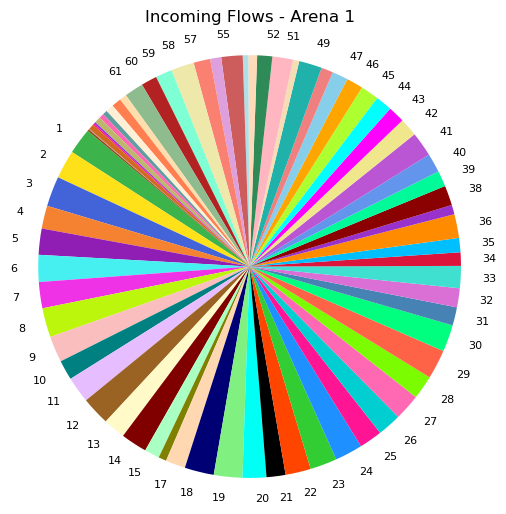

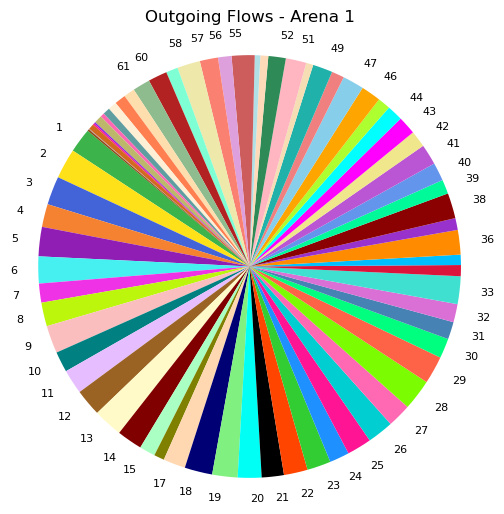


--- Incoming and Outgoing Flow Counts for Arena 2 ---
Cluster 1: Incoming = 28, Outgoing = 31
Cluster 2: Incoming = 35, Outgoing = 35
Cluster 3: Incoming = 40, Outgoing = 38
Cluster 4: Incoming = 32, Outgoing = 29
Cluster 5: Incoming = 37, Outgoing = 42
Cluster 6: Incoming = 37, Outgoing = 37
Cluster 7: Incoming = 30, Outgoing = 26
Cluster 8: Incoming = 32, Outgoing = 35
Cluster 9: Incoming = 36, Outgoing = 37
Cluster 10: Incoming = 22, Outgoing = 24
Cluster 11: Incoming = 30, Outgoing = 26
Cluster 12: Incoming = 41, Outgoing = 41
Cluster 13: Incoming = 26, Outgoing = 32
Cluster 14: Incoming = 43, Outgoing = 39
Cluster 15: Incoming = 18, Outgoing = 18
Cluster 16: Incoming = 7, Outgoing = 6
Cluster 17: Incoming = 28, Outgoing = 26
Cluster 18: Incoming = 32, Outgoing = 36
Cluster 19: Incoming = 33, Outgoing = 36
Cluster 20: Incoming = 28, Outgoing = 30
Cluster 21: Incoming = 27, Outgoing = 26
Cluster 22: Incoming = 29, Outgoing = 28
Cluster 23: Incoming = 28, Outgoing = 28
Cluster 24: I

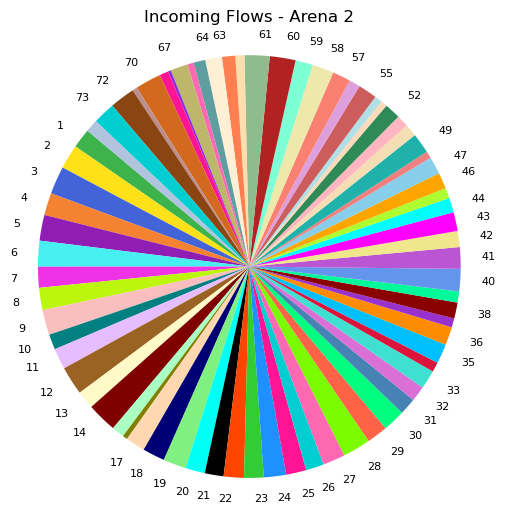

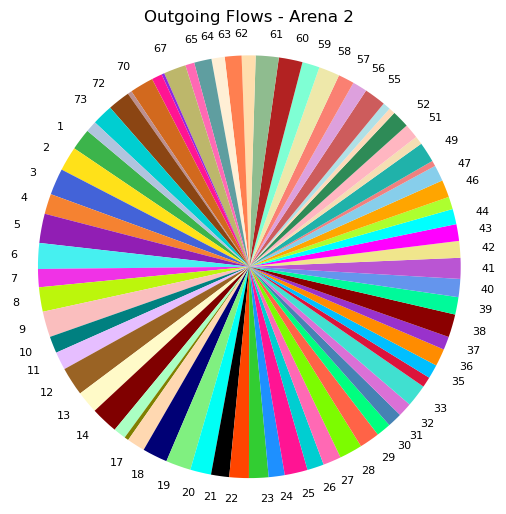


--- Incoming and Outgoing Flow Counts for Arena 3 ---
Cluster 1: Incoming = 31, Outgoing = 31
Cluster 2: Incoming = 36, Outgoing = 36
Cluster 3: Incoming = 38, Outgoing = 41
Cluster 4: Incoming = 34, Outgoing = 33
Cluster 5: Incoming = 42, Outgoing = 38
Cluster 6: Incoming = 41, Outgoing = 40
Cluster 7: Incoming = 33, Outgoing = 23
Cluster 8: Incoming = 34, Outgoing = 34
Cluster 9: Incoming = 35, Outgoing = 36
Cluster 10: Incoming = 15, Outgoing = 18
Cluster 11: Incoming = 31, Outgoing = 21
Cluster 12: Incoming = 45, Outgoing = 43
Cluster 13: Incoming = 23, Outgoing = 33
Cluster 14: Incoming = 42, Outgoing = 43
Cluster 15: Incoming = 13, Outgoing = 12
Cluster 16: Incoming = 5, Outgoing = 8
Cluster 17: Incoming = 27, Outgoing = 22
Cluster 18: Incoming = 35, Outgoing = 30
Cluster 19: Incoming = 38, Outgoing = 37
Cluster 20: Incoming = 27, Outgoing = 26
Cluster 21: Incoming = 21, Outgoing = 23
Cluster 22: Incoming = 27, Outgoing = 31
Cluster 23: Incoming = 28, Outgoing = 30
Cluster 24: I

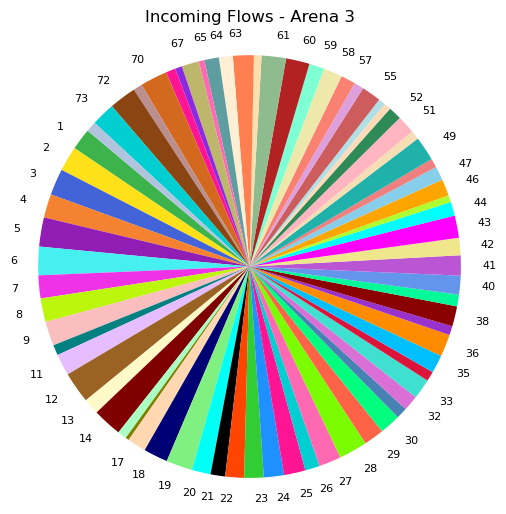

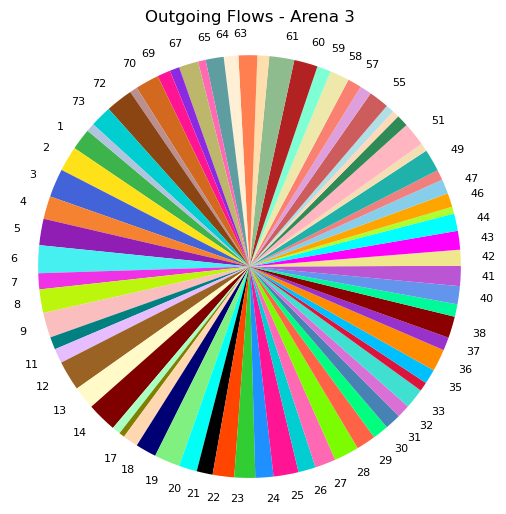


--- Incoming and Outgoing Flow Counts for Arena 4 ---
Cluster 1: Incoming = 28, Outgoing = 29
Cluster 2: Incoming = 45, Outgoing = 42
Cluster 3: Incoming = 35, Outgoing = 34
Cluster 4: Incoming = 24, Outgoing = 29
Cluster 5: Incoming = 25, Outgoing = 25
Cluster 6: Incoming = 34, Outgoing = 38
Cluster 7: Incoming = 26, Outgoing = 17
Cluster 8: Incoming = 16, Outgoing = 15
Cluster 9: Incoming = 41, Outgoing = 37
Cluster 10: Incoming = 15, Outgoing = 25
Cluster 11: Incoming = 42, Outgoing = 31
Cluster 12: Incoming = 31, Outgoing = 30
Cluster 13: Incoming = 21, Outgoing = 24
Cluster 14: Incoming = 39, Outgoing = 38
Cluster 15: Incoming = 21, Outgoing = 17
Cluster 16: Incoming = 11, Outgoing = 11
Cluster 17: Incoming = 25, Outgoing = 27
Cluster 18: Incoming = 23, Outgoing = 21
Cluster 19: Incoming = 36, Outgoing = 36
Cluster 20: Incoming = 24, Outgoing = 26
Cluster 21: Incoming = 24, Outgoing = 24
Cluster 22: Incoming = 37, Outgoing = 36
Cluster 23: Incoming = 23, Outgoing = 24
Cluster 24:

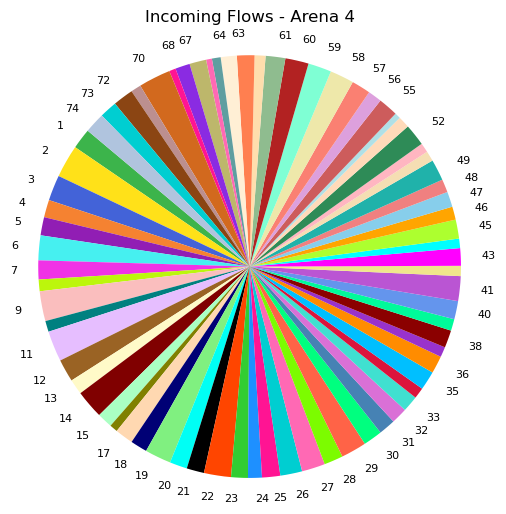

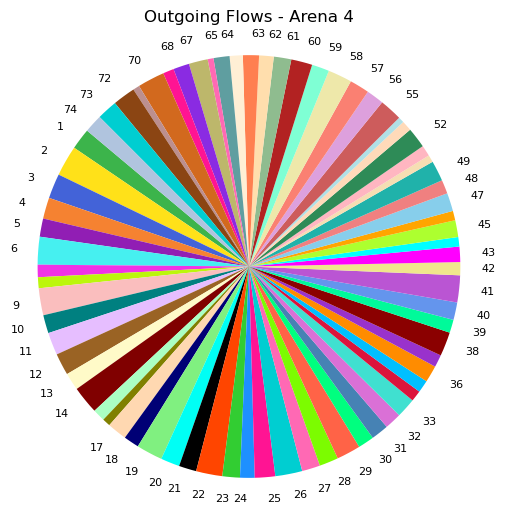


--- Incoming and Outgoing Flow Counts for Arena 5 ---
Cluster 1: Incoming = 22, Outgoing = 29
Cluster 2: Incoming = 40, Outgoing = 32
Cluster 3: Incoming = 33, Outgoing = 26
Cluster 4: Incoming = 20, Outgoing = 19
Cluster 5: Incoming = 22, Outgoing = 24
Cluster 6: Incoming = 40, Outgoing = 36
Cluster 7: Incoming = 23, Outgoing = 18
Cluster 8: Incoming = 20, Outgoing = 17
Cluster 9: Incoming = 39, Outgoing = 36
Cluster 10: Incoming = 17, Outgoing = 22
Cluster 11: Incoming = 35, Outgoing = 29
Cluster 12: Incoming = 29, Outgoing = 28
Cluster 13: Incoming = 17, Outgoing = 21
Cluster 14: Incoming = 38, Outgoing = 32
Cluster 15: Incoming = 25, Outgoing = 24
Cluster 16: Incoming = 16, Outgoing = 17
Cluster 17: Incoming = 25, Outgoing = 23
Cluster 18: Incoming = 21, Outgoing = 21
Cluster 19: Incoming = 35, Outgoing = 32
Cluster 20: Incoming = 31, Outgoing = 24
Cluster 21: Incoming = 25, Outgoing = 26
Cluster 22: Incoming = 29, Outgoing = 30
Cluster 23: Incoming = 22, Outgoing = 23
Cluster 24:

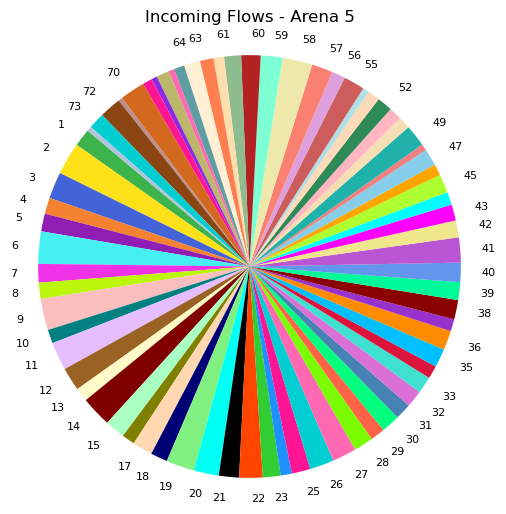

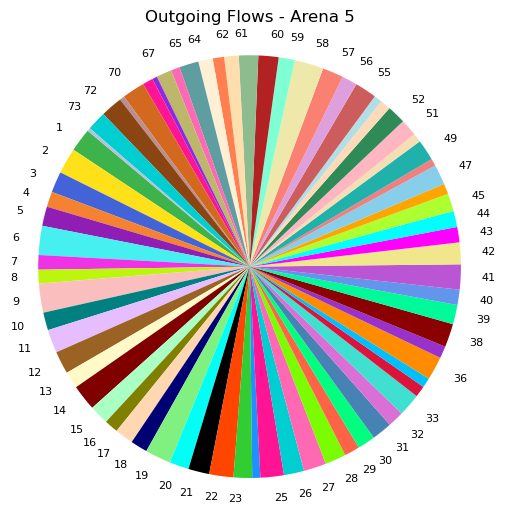


--- Incoming and Outgoing Flow Counts for All Arenas ---
Cluster 1: Incoming = 35, Outgoing = 38
Cluster 2: Incoming = 52, Outgoing = 54
Cluster 3: Incoming = 49, Outgoing = 43
Cluster 4: Incoming = 43, Outgoing = 44
Cluster 5: Incoming = 47, Outgoing = 50
Cluster 6: Incoming = 49, Outgoing = 48
Cluster 7: Incoming = 40, Outgoing = 33
Cluster 8: Incoming = 51, Outgoing = 44
Cluster 9: Incoming = 51, Outgoing = 47
Cluster 10: Incoming = 30, Outgoing = 40
Cluster 11: Incoming = 51, Outgoing = 40
Cluster 12: Incoming = 53, Outgoing = 49
Cluster 13: Incoming = 33, Outgoing = 43
Cluster 14: Incoming = 50, Outgoing = 52
Cluster 15: Incoming = 34, Outgoing = 32
Cluster 16: Incoming = 18, Outgoing = 24
Cluster 17: Incoming = 33, Outgoing = 37
Cluster 18: Incoming = 45, Outgoing = 43
Cluster 19: Incoming = 51, Outgoing = 45
Cluster 20: Incoming = 37, Outgoing = 33
Cluster 21: Incoming = 36, Outgoing = 46
Cluster 22: Incoming = 48, Outgoing = 44
Cluster 23: Incoming = 38, Outgoing = 34
Cluster 

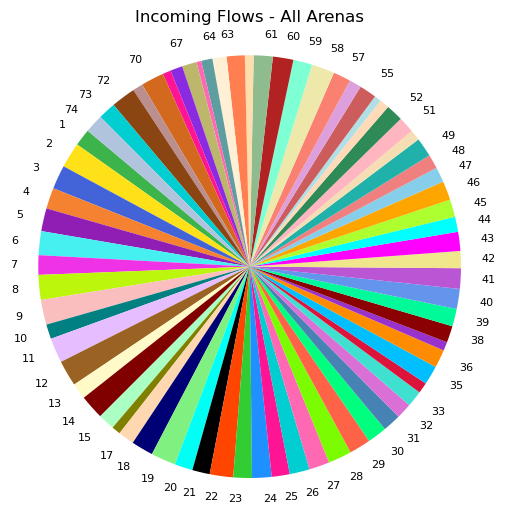

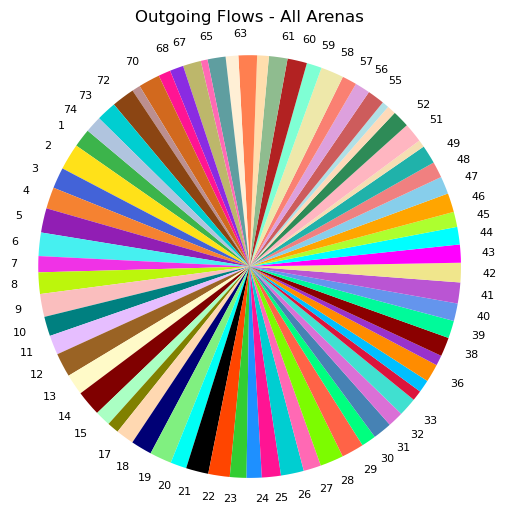

In [4]:
all_data = pd.read_csv(os.path.join(arena_data_dir, 'arena_clusters.csv'))

custom_colors = [  
    "#e6194b", "#3cb44b", "#ffe119", "#4363d8", "#f58231", "#911eb4", "#46f0f0", "#f032e6",
    "#bcf60c", "#fabebe", "#008080", "#e6beff", "#9a6324", "#fffac8", "#800000", "#aaffc3",
    "#808000", "#ffd8b1", "#000075", "#80F080", "#00FFF5", "#000000", "#ff4500", "#32cd32",
    "#1e90ff", "#ff1493", "#00ced1", "#ff69b4", "#7cfc00", "#ff6347", "#00ff7f", "#4682b4",
    "#da70d6", "#40e0d0", "#dc143c", "#00bfff", "#ff8c00", "#9932cc", "#8b0000", "#00fa9a",
    "#6495ed", "#ba55d3", "#f0e68c", "#ff00ff", "#00ffff", "#adff2f", "#ffa500", "#87ceeb",
    "#f08080", "#20b2aa", "#f5deb3", "#ffb6c1", "#2e8b57", "#ffdab9", "#b0e0e6", "#cd5c5c",
    "#dda0dd", "#fa8072", "#eee8aa", "#7fffd4", "#b22222", "#8fbc8f", "#ffdead", "#ff7f50",
    "#ffefd5", "#5f9ea0", "#ff69b4", "#bdb76b", "#8a2be2", "#ff1493", "#d2691e", "#bc8f8f",
    "#8b4513", "#00ced1", "#b0c4de", "#ffe4e1", "#2f4f4f", "#696969", "#d2b48c", "#fafad2"
]

arena_bins = [0, 12000, 24000, 36000, 48000, 60000]
arena_labels = ['Arena 1', 'Arena 2', 'Arena 3', 'Arena 4', 'Arena 5']
all_data['Arena'] = pd.cut(all_data.index, bins=arena_bins, labels=arena_labels, right=False)

def create_arena_sankey_and_pies(data, arena_name):
    data = data.copy()
    data['Next_Cluster'] = data['Cluster Index'].shift(-1)
    data['Next_Arena'] = data['Arena'].shift(-1)
    data = data[data['Arena'] == data['Next_Arena']]

    transition_counts = data.groupby(['Cluster Index', 'Next_Cluster']).size().unstack(fill_value=0)
    transition_probabilities = transition_counts.div(transition_counts.sum(axis=1), axis=0)
    all_clusters = sorted(data['Cluster Index'].dropna().astype(int).unique())
    outgoing_counts = {f"Cluster {i}": 0 for i in all_clusters}
    incoming_counts = {f"Cluster {i}": 0 for i in all_clusters}

    for col in transition_probabilities.columns:
        for row in transition_probabilities.index:
            prob = transition_probabilities.at[row, col]
            if prob > 0:
                src = f"Cluster {int(row)}"
                tgt = f"Cluster {int(col)}"
                if src in outgoing_counts:
                    outgoing_counts[src] += 1
                if tgt in incoming_counts:
                    incoming_counts[tgt] += 1

    print(f"\n--- Incoming and Outgoing Flow Counts for {arena_name} ---")
    for clust in all_clusters:
        cname = f"Cluster {clust}"
        print(f"{cname}: Incoming = {incoming_counts.get(cname, 0)}, Outgoing = {outgoing_counts.get(cname, 0)}")


    def plot_pie_chart(counts, title):
        labels = list(counts.keys())
        sizes = list(counts.values())
        total = sum(sizes)

        display_labels = [
            label.replace("Cluster ", "") if (value / total * 100) >= 1 else ""
            for label, value in zip(labels, sizes)
        ]

        pie_colors = [custom_colors[int(label.split()[1]) % len(custom_colors)] for label in labels]

        plt.figure(figsize=(6, 6))
        plt.pie(
            sizes,
            labels=display_labels,
            colors=pie_colors,
            startangle=140,
            textprops={'fontsize': 8}
        )
        plt.title(title, pad=10)
        plt.axis('equal')
        plt.show()

    incoming_chart_counts = {k: v for k, v in incoming_counts.items() if v > 0}
    outgoing_chart_counts = {k: v for k, v in outgoing_counts.items() if v > 0}

    plot_pie_chart(incoming_chart_counts, f"Incoming Flows - {arena_name}")
    plot_pie_chart(outgoing_chart_counts, f"Outgoing Flows - {arena_name}")


for arena_label in arena_labels:
    arena_data = all_data[all_data['Arena'] == arena_label]
    create_arena_sankey_and_pies(arena_data, arena_label)


create_arena_sankey_and_pies(all_data, "All Arenas")


In [5]:
all_data_path = pd.read_csv(os.path.join(arena_data_dir, 'arena_clusters.csv'))
group_path = pd.read_csv(os.path.join(arena_data_dir, '428_arena_grouped_clusters.csv'))

arena_bins = [0, 12000, 24000, 36000, 48000, 60000]
arena_labels = ['Arena 1', 'Arena 2', 'Arena 3', 'Arena 4', 'Arena 5']
data['Arena'] = pd.cut(data.index, bins=arena_bins, labels=arena_labels, right=False)

custom_colors = [
    "#e6194b", "#3cb44b", "#ffe119", "#4363d8", "#f58231", "#911eb4", "#46f0f0", "#f032e6",
    "#bcf60c", "#fabebe", "#008080", "#e6beff", "#9a6324", "#fffac8", "#800000", "#aaffc3",
    "#808000", "#ffd8b1", "#000075", "#80F080", "#00FFF5", "#000000", "#ff4500", "#32cd32"
]

group_list = sorted(grouped_clusters['Group'].dropna().unique())
color_map = {int(group): custom_colors[i % len(custom_colors)] for i, group in enumerate(group_list)}

def map_grouped_clusters(df):
    return df.merge(grouped_clusters[['Cluster', 'Group']], left_on='Cluster Index', right_on='Cluster', how='left')

def create_grouped_sankey_plot(data, arena_name):
    data = map_grouped_clusters(data)
    data['Next_Group'] = data['Group'].shift(-1)
    data = data.dropna(subset=['Group', 'Next_Group'])

    data['Group'] = data['Group'].astype(int)
    data['Next_Group'] = data['Next_Group'].astype(int)

    unique_groups = sorted(set(data['Group']).union(set(data['Next_Group'])))
    group_labels = [f"Group {g}" for g in unique_groups]
    label_indices = {f"Group {g}": i for i, g in enumerate(unique_groups)}
    n = len(unique_groups)

    transition_counts = data.groupby(['Group', 'Next_Group']).size().unstack(fill_value=0)
    transition_probs = transition_counts.div(transition_counts.sum(axis=1), axis=0)

    source, target, values, colors = [], [], [], []

    for src in transition_probs.index:
        for tgt in transition_probs.columns:
            prob = transition_probs.at[src, tgt]
            if prob > 0:
                src_label = f"Group {src}"
                tgt_label = f"Group {tgt}"
                source.append(label_indices[src_label])
                target.append(label_indices[tgt_label] + n)
                values.append(prob)
                colors.append(color_map[src])

    scale = 0.6 
    offset = (1 - scale) / 2 
    y_values = [offset + scale * (i / (n - 1)) for i in range(n)] if n > 1 else [0.5]
    vertical_shift = -0.03 
    y_positions = y_values * 2



    x_positions = [0.1] * n + [0.9] * n

    fig = go.Figure(go.Sankey(
        node=dict(
            pad=20,
            thickness=25,
            line=dict(color="black", width=0.5),
            label=group_labels * 2,
            color="lightgray",
            x=x_positions,
            y=y_positions
        ),
        link=dict(
            source=source,
            target=target,
            value=values,
            color=colors
        )
    ))

    fig.update_layout(
        title_text=f"Grouped Cluster Transitions in {arena_name}",
        font_size=12,
        height=1000,
        width=1000,
        margin=dict(l=10, r=100, t=50, b=50) 
    )

    fig.show()


for arena in data['Arena'].dropna().unique():
    create_grouped_sankey_plot(data[data['Arena'] == arena], arena)

create_grouped_sankey_plot(data, "All Arenas")


--- Group Flow Counts for Arena 1 ---
Group 1: Incoming = 47, Outgoing = 47
Group 2: Incoming = 2, Outgoing = 2
Group 3: Incoming = 1, Outgoing = 1
Group 4: Incoming = 448, Outgoing = 448
Group 5: Incoming = 37, Outgoing = 37
Group 6: Incoming = 699, Outgoing = 698
Group 7: Incoming = 2, Outgoing = 2
Group 8: Incoming = 2168, Outgoing = 2168
Group 9: Incoming = 8595, Outgoing = 8596


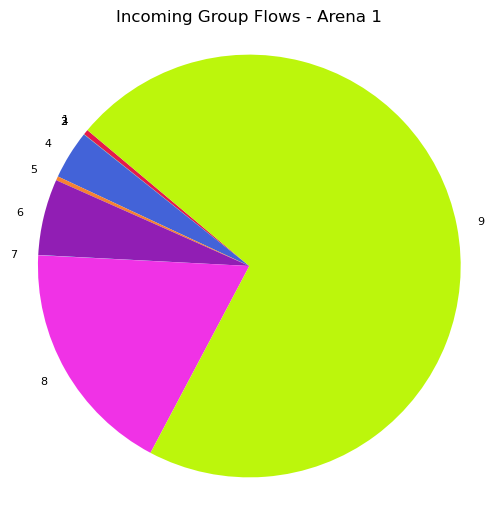

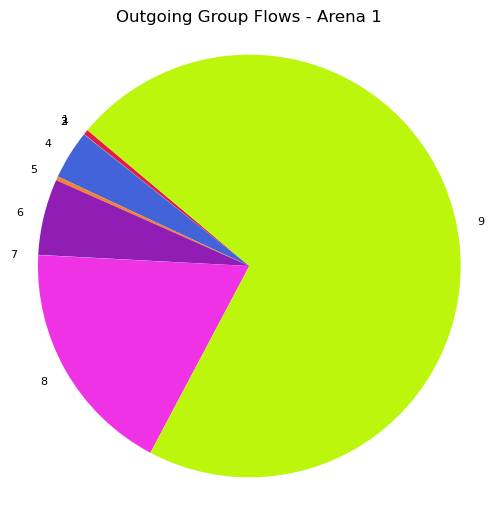

--- Group Flow Counts for Arena 2 ---
Group 1: Incoming = 15, Outgoing = 15
Group 2: Incoming = 9, Outgoing = 9
Group 3: Incoming = 23, Outgoing = 23
Group 4: Incoming = 991, Outgoing = 991
Group 5: Incoming = 9, Outgoing = 9
Group 6: Incoming = 943, Outgoing = 943
Group 7: Incoming = 174, Outgoing = 174
Group 8: Incoming = 2471, Outgoing = 2470
Group 9: Incoming = 7364, Outgoing = 7365


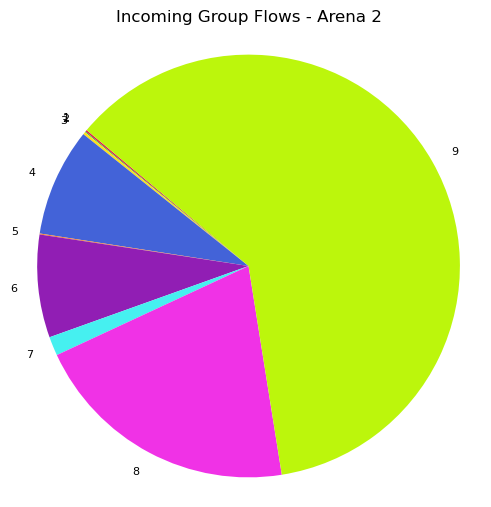

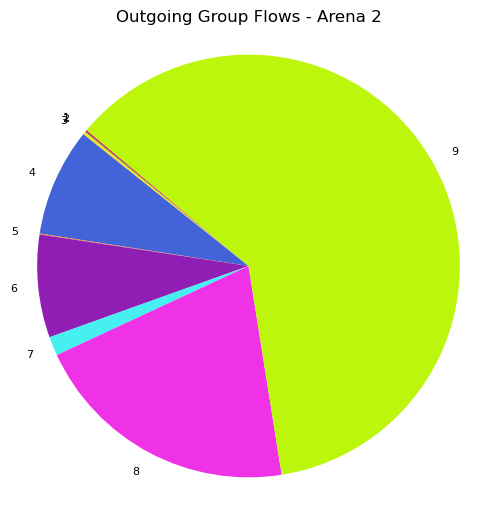

--- Group Flow Counts for Arena 3 ---
Group 1: Incoming = 47, Outgoing = 47
Group 2: Incoming = 17, Outgoing = 17
Group 3: Incoming = 45, Outgoing = 45
Group 4: Incoming = 733, Outgoing = 733
Group 5: Incoming = 13, Outgoing = 13
Group 6: Incoming = 837, Outgoing = 838
Group 7: Incoming = 202, Outgoing = 202
Group 8: Incoming = 2241, Outgoing = 2240
Group 9: Incoming = 7864, Outgoing = 7864


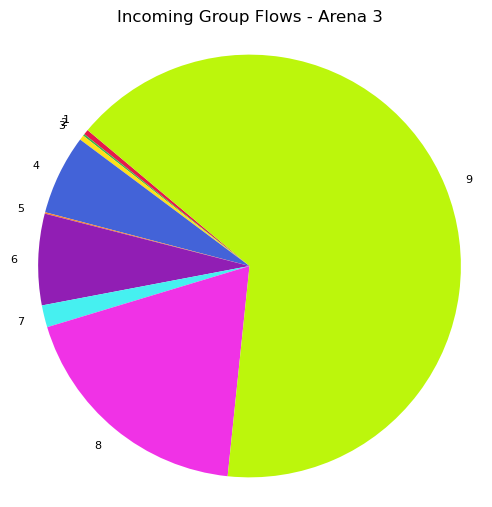

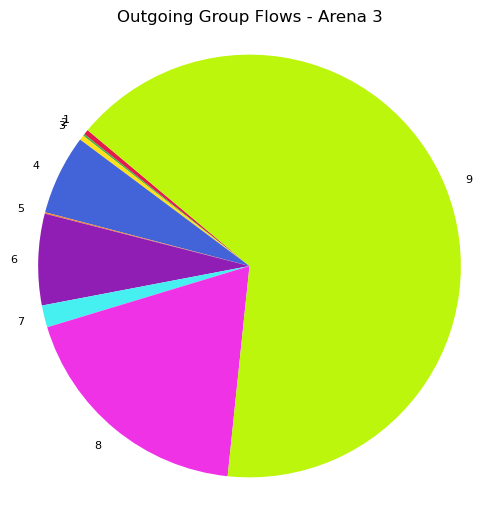

--- Group Flow Counts for Arena 4 ---
Group 1: Incoming = 51, Outgoing = 51
Group 2: Incoming = 93, Outgoing = 93
Group 3: Incoming = 80, Outgoing = 80
Group 4: Incoming = 1304, Outgoing = 1304
Group 5: Incoming = 62, Outgoing = 62
Group 6: Incoming = 844, Outgoing = 844
Group 7: Incoming = 205, Outgoing = 205
Group 8: Incoming = 3532, Outgoing = 3533
Group 9: Incoming = 5828, Outgoing = 5827


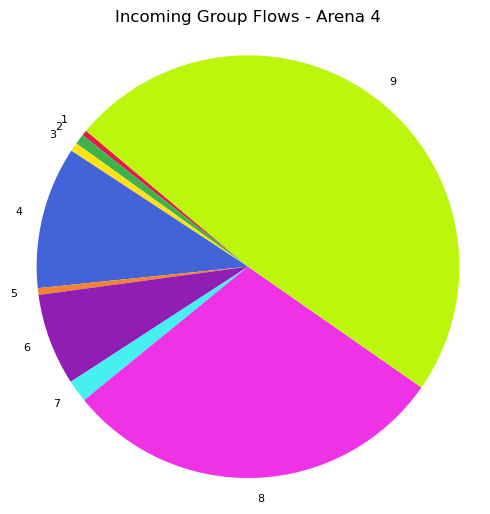

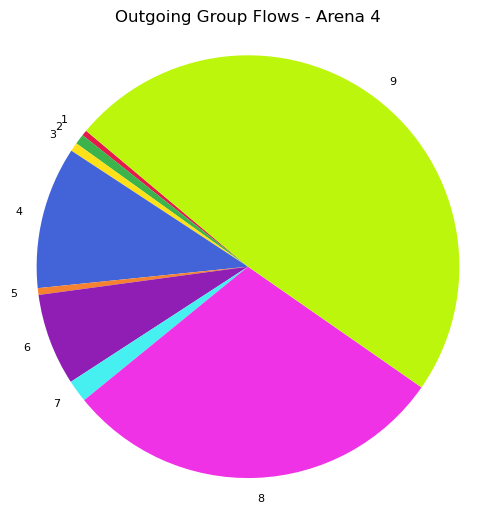

--- Group Flow Counts for Arena 5 ---
Group 1: Incoming = 22, Outgoing = 22
Group 2: Incoming = 9, Outgoing = 9
Group 3: Incoming = 24, Outgoing = 24
Group 4: Incoming = 1034, Outgoing = 1033
Group 5: Incoming = 160, Outgoing = 160
Group 6: Incoming = 520, Outgoing = 520
Group 7: Incoming = 54, Outgoing = 54
Group 8: Incoming = 1372, Outgoing = 1372
Group 9: Incoming = 8227, Outgoing = 8228


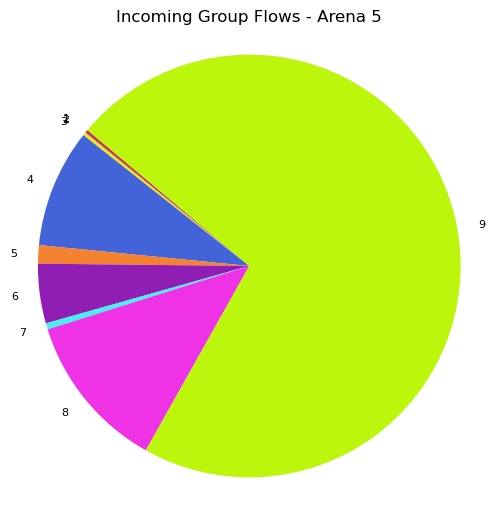

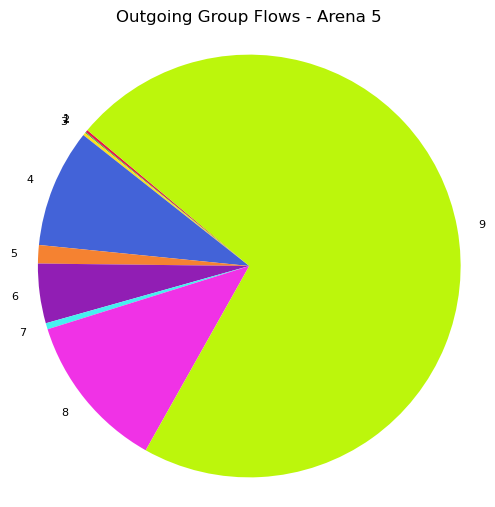

--- Group Flow Counts for All Arenas ---
Group 1: Incoming = 182, Outgoing = 182
Group 2: Incoming = 130, Outgoing = 130
Group 3: Incoming = 173, Outgoing = 173
Group 4: Incoming = 4510, Outgoing = 4509
Group 5: Incoming = 281, Outgoing = 281
Group 6: Incoming = 3844, Outgoing = 3844
Group 7: Incoming = 637, Outgoing = 637
Group 8: Incoming = 11785, Outgoing = 11785
Group 9: Incoming = 37880, Outgoing = 37881


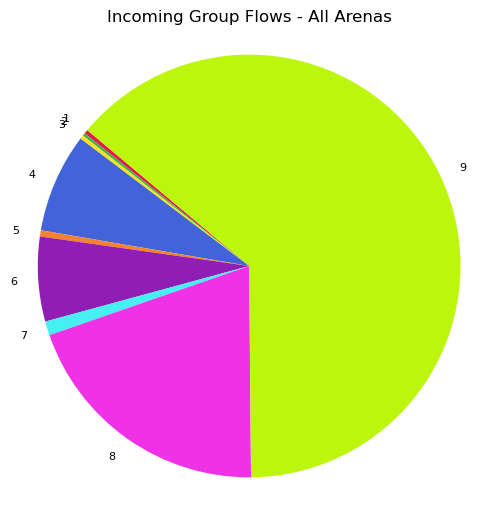

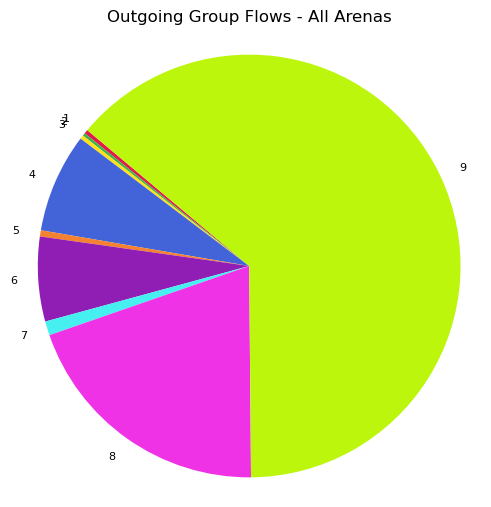

In [6]:

arena_bins = [0, 12000, 24000, 36000, 48000, 60000]
arena_labels = ['Arena 1', 'Arena 2', 'Arena 3', 'Arena 4', 'Arena 5']
all_data['Arena'] = pd.cut(all_data.index, bins=arena_bins, labels=arena_labels, right=False)
cluster_to_group = dict(zip(grouped_clusters['Cluster'], grouped_clusters['Group']))
all_data['Group'] = all_data['Cluster Index'].map(cluster_to_group)

custom_colors = [
    "#32cd32", "#e6194b", "#3cb44b", "#ffe119", "#4363d8", "#f58231", "#911eb4", "#46f0f0", "#f032e6",
    "#bcf60c", "#fabebe", "#008080", "#e6beff", "#9a6324", "#fffac8", "#800000", "#aaffc3",
    "#808000", "#ffd8b1", "#000075", "#80F080", "#00FFF5", "#000000", "#ff4500", "#32cd32",
]

def create_group_pie_flows(data, arena_name):
    data = data.copy()
    data['Next_Group'] = data['Group'].shift(-1)
    data = data.dropna(subset=['Group', 'Next_Group'])

    data['Group'] = data['Group'].astype(int)
    data['Next_Group'] = data['Next_Group'].astype(int)

    all_groups = sorted(set(data['Group']).union(set(data['Next_Group'])))
    outgoing_counts = {f"Group {i}": 0 for i in all_groups}
    incoming_counts = {f"Group {i}": 0 for i in all_groups}

    for _, row in data.iterrows():
        src = f"Group {row['Group']}"
        tgt = f"Group {row['Next_Group']}"
        outgoing_counts[src] += 1
        incoming_counts[tgt] += 1

    print(f"--- Group Flow Counts for {arena_name} ---")
    for g in all_groups:
        gname = f"Group {g}"
        print(f"{gname}: Incoming = {incoming_counts[gname]}, Outgoing = {outgoing_counts[gname]}")

    def plot_pie_chart(counts, title):
        labels = list(counts.keys())
        sizes = list(counts.values())
        pie_colors = [custom_colors[int(label.split()[-1]) % len(custom_colors)] for label in labels]
        plt.figure(figsize=(6, 6))
        plt.pie(
            sizes,
            labels=[label.replace("Group ", "") for label in labels],
            colors=pie_colors,
            startangle=140,
            textprops={'fontsize': 8}
        )
        plt.title(title, pad=10)
        plt.axis('equal')
        plt.show()

    incoming_chart = {k: v for k, v in incoming_counts.items() if v > 0}
    outgoing_chart = {k: v for k, v in outgoing_counts.items() if v > 0}

    plot_pie_chart(incoming_chart, f"Incoming Group Flows - {arena_name}")
    plot_pie_chart(outgoing_chart, f"Outgoing Group Flows - {arena_name}")

for arena_label in arena_labels:
    arena_data = all_data[all_data['Arena'] == arena_label]
    if not arena_data.empty:
        create_group_pie_flows(arena_data, arena_label)

create_group_pie_flows(all_data, "All Arenas")
